<a href="https://colab.research.google.com/github/scientificbroker/business-analytics-para-startups/blob/main/Code%20Colabs/M4_KMeans_Segmentacion_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M4 — KMeans: Segmentación de Clientes para Startups LATAM

**Caso de uso:** Marketplace de delivery de alimentos (B2C)  
*(Inspirado en Rappi, iFood, PedidosYa, Cornershop)*

---

## Objetivos del módulo

1. Calcular métricas RFM (Recency, Frequency, Monetary) por cliente
2. Encontrar el número óptimo de clusters con Elbow Method y Silhouette Score
3. Entrenar el modelo KMeans y asignar segmentos a cada cliente
4. Perfilar cada segmento con nombres de negocio accionables
5. Visualizar la distribución de clientes y revenue por segmento
6. Exportar lista de clientes segmentada lista para el CRM

---

**Modelo RFM (estándar global adaptado a LATAM):**
| Dimensión | Definición | Interpretación |
|---|---|---|
| **R** (Recency) | Días desde el último pedido | Menor = mejor |
| **F** (Frequency) | N° de pedidos en últimos 90 días | Mayor = mejor |
| **M** (Monetary) | Gasto total en últimos 90 días (USD) | Mayor = mejor |

> **Repositorio:** [business-analytics-para-startups](https://github.com/scientificbroker/business-analytics-para-startups)

## 0. Instalación de dependencias

In [1]:
# Instala las dependencias necesarias (ejecuta solo una vez en Google Colab)
%pip install scikit-learn pandas numpy matplotlib seaborn -q


## 1. Configuración de parámetros

In [2]:
# ════════════════════════════════════════════════
# PARÁMETROS CONFIGURABLES
# ════════════════════════════════════════════════

N_CLIENTES       = 1500
RANDOM_SEED      = 42
VENTANA_RFM_DIAS = 90   # ventana de análisis en días
K_FINAL          = 4    # número de segmentos para el negocio
                        # 4 = Campeones, Leales, En Riesgo, Hibernando

# Para cargar datos reales (columnas mínimas requeridas):
# df = pd.read_csv('transacciones.csv')  # cliente_id, fecha_compra, monto
# Luego calcular RFM con groupby

## 2. Importaciones

In [3]:
%matplotlib inline
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
COLORES_SEGMENTO = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB', 3: '#F39C12'}
plt.rcParams.update({'figure.figsize': (13, 7), 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
np.random.seed(RANDOM_SEED)

print('Modulo 4: KMeans — Segmentacion Marketplace LATAM')
print('Similar a: Rappi, iFood, PedidosYa, Cornershop')


Modulo 4: KMeans — Segmentacion Marketplace LATAM
Similar a: Rappi, iFood, PedidosYa, Cornershop


## 3. Generación de datos transaccionales

Simulamos 4 perfiles de clientes que el algoritmo deberá descubrir por sí solo (sin decirle cuáles son).  
Esto replica la realidad de marketplaces LATAM donde la base tiene comportamientos muy distintos:

| Perfil | Descripción |
|---|---|
| **Campeones** | Compran seguido, gastaron mucho recientemente |
| **Leales** | Buenos clientes, no los más frecuentes |
| **En Riesgo** | Antes compraban, ahora cada vez menos |
| **Hibernando** | Casi no compran, poco gasto |

In [4]:
FECHA_HOY = datetime(2026, 4, 8)

paises   = ['México', 'Brasil', 'Argentina', 'Colombia', 'Chile']
p_pais   = [0.25, 0.30, 0.20, 0.15, 0.10]
ciudades = ['CDMX', 'São Paulo', 'Buenos Aires', 'Bogotá', 'Santiago',
            'Guadalajara', 'Río de Janeiro', 'Córdoba', 'Medellín', 'Valparaíso']

# (nombre, n_usuarios, recency_max, freq_media, monto_medio_ticket)
PERFILES = [
    ('Campeones', 200, 7,  15, 28),
    ('Leales',    350, 20, 8,  22),
    ('En_riesgo', 400, 65, 5,  18),
    ('Hibernando',550, 85, 2,  12),
]

transacciones = []
for perfil, n_users, rec_max, freq_m, ticket_m in PERFILES:
    for i in range(n_users):
        recency = max(1, int(np.random.uniform(1, rec_max * 1.5)))
        freq    = max(1, int(np.random.poisson(freq_m)))
        monto   = round(np.random.lognormal(np.log(ticket_m * freq), 0.4), 2)
        transacciones.append({
            'cliente_id':       f'{perfil[:3].upper()}-{i:05d}',
            'pais':             np.random.choice(paises, p=p_pais),
            'ciudad':           np.random.choice(ciudades),
            'recency_dias':     recency,
            'freq_90d':         freq,
            'monto_90d_usd':    monto,
            'ticket_prom_usd':  round(monto / freq, 2),
            'n_categorias':     np.random.randint(1, 7),
            'usar_app_movil':   np.random.choice([1, 0], p=[0.85, 0.15]),
            'usa_descuentos':   np.random.choice([1, 0], p=[0.40, 0.60]),
            'nps_ultimo':       np.random.choice(range(5, 11), p=[0.05, 0.05, 0.10, 0.20, 0.30, 0.30]),
            'perfil_real':      perfil,
        })

df = pd.DataFrame(transacciones)
print(f'Dataset creado: {len(df)} clientes con métricas RFM')
print(f'Gasto promedio 90 días: ${df["monto_90d_usd"].mean():.2f} USD')
print(f'Frecuencia promedio: {df["freq_90d"].mean():.1f} pedidos/90 días')

Dataset creado: 1500 clientes con métricas RFM
Gasto promedio 90 días: $146.02 USD
Frecuencia promedio: 6.0 pedidos/90 días


## 4. Normalización de features RFM

**¿Por qué normalizar?** Sin normalización, la variable `monto` (que puede valer 500) dominaría sobre `recency` (que puede valer 30), aunque ambas tengan igual importancia para el negocio.  

StandardScaler transforma cada variable para que tenga media=0 y std=1, dando **igual peso** a las tres dimensiones RFM.

In [5]:
FEATURES_CLUSTER = ['recency_dias', 'freq_90d', 'monto_90d_usd']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES_CLUSTER])

print('Estadísticas RFM antes de normalizar:')
display(df[FEATURES_CLUSTER].describe().round(2))
print('\nVariables normalizadas con StandardScaler (media=0, std=1)')

Estadísticas RFM antes de normalizar:


,recency_dias,freq_90d,monto_90d_usd
count,1500.00,1500.00,1500.00
mean,41.44,5.97,146.02
std,35.97,4.85,188.67
min,1.00,1.00,3.34
25%,10.00,2.00,28.63
50%,28.00,5.00,78.78
75%,70.00,8.00,189.88
max,127.00,26.00,2469.70



Variables normalizadas con StandardScaler (media=0, std=1)


## 5. Selección del número óptimo de clusters (K)

**Dos métodos complementarios:**

- **Elbow Method:** grafica la inercia (suma de distancias al centroide) vs K. El "codo" de la curva es donde agregar más clusters deja de reducir significativamente la inercia.

- **Silhouette Score:** mide qué tan bien separados están los clusters (entre -1 y +1). Valores > 0.50 indican estructura clara. Seleccionar el K con el score más alto.

**Nota:** el K matemáticamente óptimo puede no ser el mejor para negocio. Usamos K=4 porque genera 4 segmentos accionables que tienen sentido operacional para un marketplace.

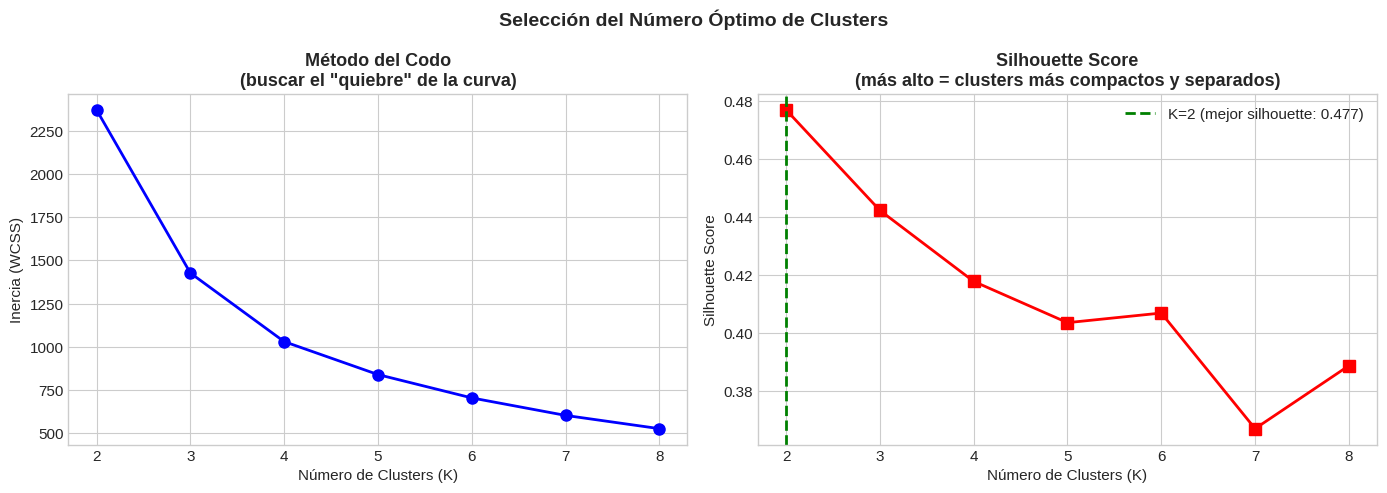

K óptimo sugerido por Silhouette: K=2
Silhouette Score: 0.477  (>0.50 = estructura clara)
K seleccionado para negocio: K=4 (4 segmentos accionables)


In [6]:
K_RANGE     = range(2, 9)
inercias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_, sample_size=500))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Selección del Número Óptimo de Clusters', fontsize=14, fontweight='bold')

axes[0].plot(list(K_RANGE), inercias, 'bo-', lw=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo\n(buscar el "quiebre" de la curva)')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(list(K_RANGE), silhouettes, 'rs-', lw=2, markersize=8)
mejor_k_idx = silhouettes.index(max(silhouettes))
mejor_k     = list(K_RANGE)[mejor_k_idx]
axes[1].axvline(mejor_k, color='green', linestyle='--', lw=2,
                label=f'K={mejor_k} (mejor silhouette: {max(silhouettes):.3f})')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score\n(más alto = clusters más compactos y separados)')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.tight_layout()
plt.savefig('M4_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'K óptimo sugerido por Silhouette: K={mejor_k}')
print(f'Silhouette Score: {max(silhouettes):.3f}  (>0.50 = estructura clara)')
print(f'K seleccionado para negocio: K={K_FINAL} (4 segmentos accionables)')

## 6. Entrenamiento KMeans y perfilado de segmentos

Los **centroides** son el perfil promedio de cada cluster — los usamos para ponerles nombre de negocio.

El cluster con menor recency + mayor frecuencia + mayor monto = **Campeones**.  
El cluster con mayor recency + menor frecuencia + menor monto = **Hibernando**.

In [7]:
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_SEED, n_init=20, max_iter=500)
df['cluster_id'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster_id'], sample_size=500)
print(f'Silhouette Score final (K={K_FINAL}): {sil_final:.3f}')

centroides = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=FEATURES_CLUSTER
).round(2)
centroides.index.name = 'cluster_id'

print('\nCentroides en escala original (perfil promedio de cada segmento):')
display(centroides)

# Asignar nombres de negocio según perfil RFM
def score_rfm(row):
    return (1 / (row['recency_dias'] + 1)) * 100 + row['freq_90d'] * 10 + row['monto_90d_usd'] * 0.5

centroides['score'] = centroides.apply(score_rfm, axis=1)
centroides_sorted   = centroides.sort_values('score', ascending=False).reset_index()

nombres_segmento = {
    0: ('Campeones',      '#2ECC71', 'Recompensar, activar como embajadores, cross-sell premium'),
    1: ('Leales Activos', '#3498DB', 'Programa de fidelidad, upsell, encuesta NPS'),
    2: ('En Riesgo',      '#F39C12', 'Campaña win-back urgente, descuento personalizado'),
    3: ('Hibernando',     '#E74C3C', 'Email de reactivación, oferta única, evaluar costo'),
}

mapa_cluster = {}
for rank, (_, row) in enumerate(centroides_sorted.iterrows()):
    cluster_id = row['cluster_id']
    mapa_cluster[cluster_id] = nombres_segmento[rank]

df['segmento']       = df['cluster_id'].map(lambda x: mapa_cluster[x][0])
df['color_segmento'] = df['cluster_id'].map(lambda x: mapa_cluster[x][1])

resumen_seg = df.groupby('segmento').agg(
    n_clientes         = ('cliente_id', 'count'),
    recency_prom       = ('recency_dias', 'mean'),
    freq_prom          = ('freq_90d', 'mean'),
    monto_prom_90d     = ('monto_90d_usd', 'mean'),
    ticket_prom        = ('ticket_prom_usd', 'mean'),
    nps_prom           = ('nps_ultimo', 'mean'),
    usa_descuentos_pct = ('usa_descuentos', 'mean'),
).round(2)
resumen_seg['pct_base'] = (resumen_seg['n_clientes'] / len(df) * 100).round(1)

print('\nPerfil de Segmentos:')
display(resumen_seg)

print('\nEstrategias por Segmento:')
for rank, (nombre, color, estrategia) in nombres_segmento.items():
    print(f'  {nombre:<18} → {estrategia}')

Silhouette Score final (K=4): 0.432

Centroides en escala original (perfil promedio de cada segmento):


,recency_dias,freq_90d,monto_90d_usd
cluster_id,,,
0,14.73,9.57,234.16
1,26.29,3.46,61.77
2,5.92,17.53,631.03
3,87.67,3.02,50.07



Perfil de Segmentos:


,n_clientes,recency_prom,freq_prom,monto_prom_90d,ticket_prom,nps_prom,usa_descuentos_pct,pct_base
segmento,,,,,,,,
Campeones,115,5.92,17.53,631.03,36.82,8.55,0.41,7.7
En Riesgo,518,26.29,3.46,61.77,16.85,8.55,0.41,34.5
Hibernando,481,87.67,3.02,50.07,15.43,8.70,0.43,32.1
Leales Activos,386,14.73,9.57,234.16,25.26,8.55,0.38,25.7



Estrategias por Segmento:
  Campeones          → Recompensar, activar como embajadores, cross-sell premium
  Leales Activos     → Programa de fidelidad, upsell, encuesta NPS
  En Riesgo          → Campaña win-back urgente, descuento personalizado
  Hibernando         → Email de reactivación, oferta única, evaluar costo


## 7. Visualizaciones del análisis de segmentación

Cuatro visualizaciones que cuentan la historia completa del análisis:
1. **Scatter RFM:** posición relativa de cada segmento en el espacio de comportamiento
2. **Distribución:** cuántos clientes hay en cada segmento
3. **Revenue:** quién genera el dinero (los Campeones suelen ser pocos pero muy valiosos)
4. **Heatmap de perfil:** fortalezas y debilidades de cada segmento

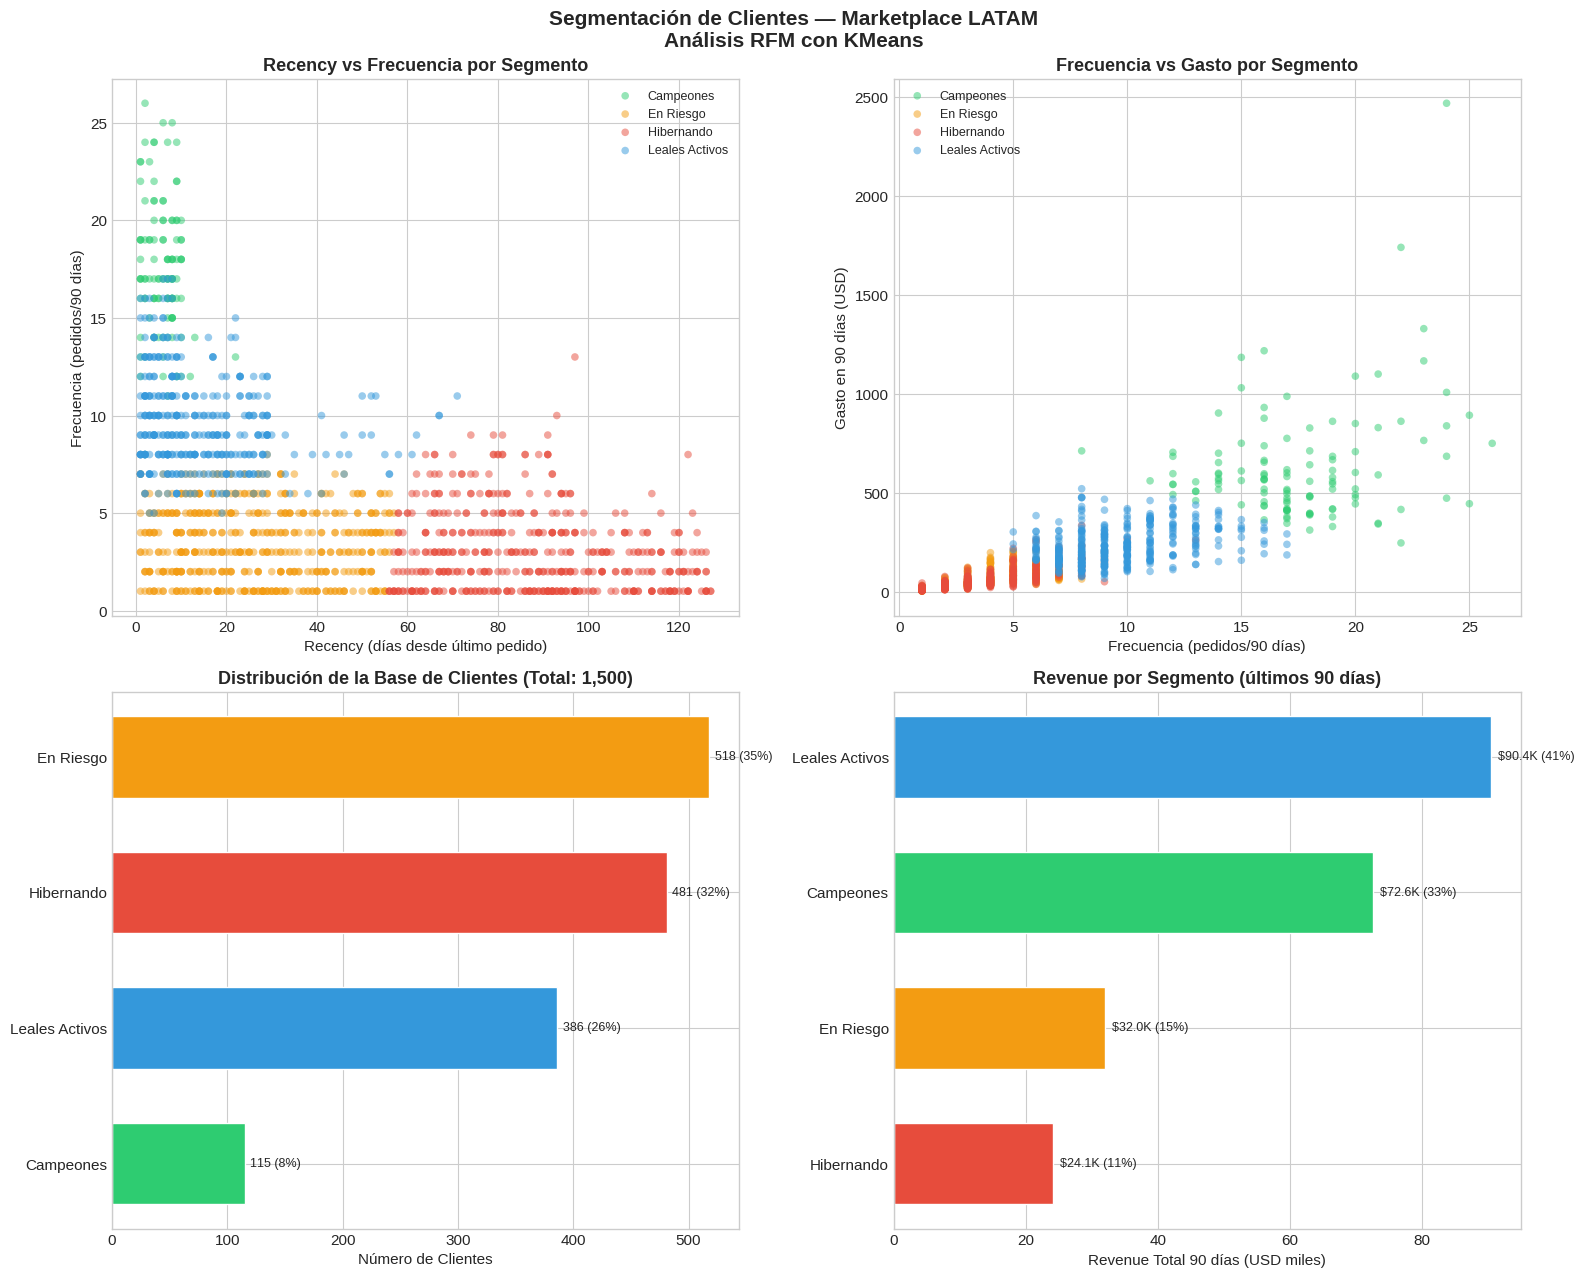

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Segmentación de Clientes — Marketplace LATAM\nAnálisis RFM con KMeans',
             fontsize=15, fontweight='bold')

# Plot 1: Recency vs Frequency
ax1 = axes[0, 0]
for seg_name, group in df.groupby('segmento'):
    color = [v[1] for v in nombres_segmento.values() if v[0] == seg_name][0]
    ax1.scatter(group['recency_dias'], group['freq_90d'],
                c=color, alpha=0.5, s=30, label=seg_name, edgecolors='none')
ax1.set_xlabel('Recency (días desde último pedido)')
ax1.set_ylabel('Frecuencia (pedidos/90 días)')
ax1.set_title('Recency vs Frecuencia por Segmento')
ax1.legend(fontsize=9)

# Plot 2: Frequency vs Monto
ax2 = axes[0, 1]
for seg_name, group in df.groupby('segmento'):
    color = [v[1] for v in nombres_segmento.values() if v[0] == seg_name][0]
    ax2.scatter(group['freq_90d'], group['monto_90d_usd'],
                c=color, alpha=0.5, s=30, label=seg_name, edgecolors='none')
ax2.set_xlabel('Frecuencia (pedidos/90 días)')
ax2.set_ylabel('Gasto en 90 días (USD)')
ax2.set_title('Frecuencia vs Gasto por Segmento')
ax2.legend(fontsize=9)

# Plot 3: Distribución de clientes
ax3 = axes[1, 0]
seg_counts  = resumen_seg['n_clientes'].sort_values(ascending=True)
seg_colors3 = [df[df['segmento'] == s]['color_segmento'].iloc[0] for s in seg_counts.index]
bars = ax3.barh(seg_counts.index, seg_counts.values, color=seg_colors3, edgecolor='white', height=0.6)
ax3.set_xlabel('Número de Clientes')
ax3.set_title(f'Distribución de la Base de Clientes (Total: {len(df):,})')
for bar, val in zip(bars, seg_counts.values):
    pct = val / len(df) * 100
    ax3.text(val + 5, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({pct:.0f}%)', va='center', fontsize=9)

# Plot 4: Revenue por segmento
ax4 = axes[1, 1]
revenue_seg = df.groupby('segmento')['monto_90d_usd'].sum().sort_values(ascending=True)
rev_colors  = [df[df['segmento'] == s]['color_segmento'].iloc[0] for s in revenue_seg.index]
bars4 = ax4.barh(revenue_seg.index, revenue_seg.values / 1000,
                 color=rev_colors, edgecolor='white', height=0.6)
ax4.set_xlabel('Revenue Total 90 días (USD miles)')
ax4.set_title('Revenue por Segmento (últimos 90 días)')
total_rev = revenue_seg.sum()
for bar, val in zip(bars4, revenue_seg.values):
    ax4.text(val/1000 + total_rev/1000*0.005, bar.get_y() + bar.get_height()/2,
             f'${val/1000:.1f}K ({val/total_rev:.0%})', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('M4_segmentacion_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Heatmap de perfiles normalizados

Esta visualización es ideal para **presentaciones a inversores** — muestra de un vistazo las fortalezas y debilidades de cada segmento.

- **Verde** = el segmento es fuerte en esa métrica
- **Rojo** = el segmento es débil en esa métrica → oportunidad de mejora

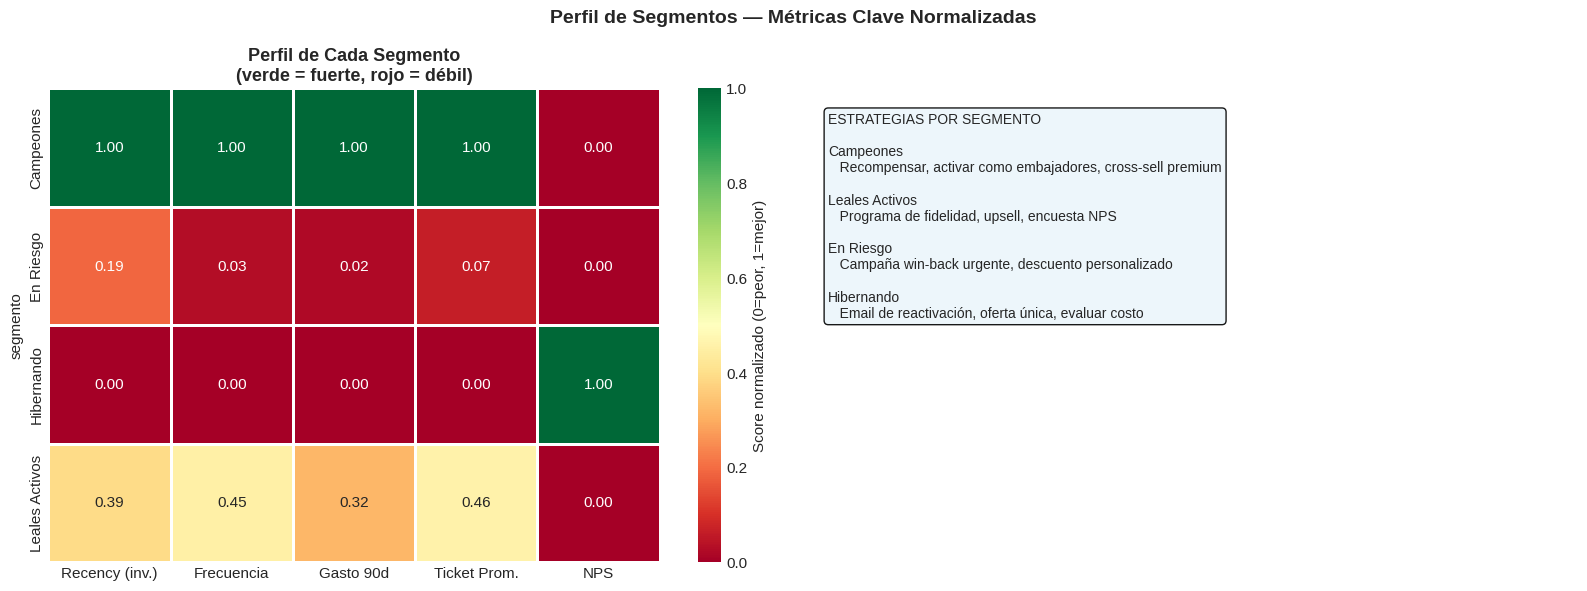

Lista exportada: M4_clientes_segmentados.csv (lista para subir al CRM)


In [9]:
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle('Perfil de Segmentos — Métricas Clave Normalizadas', fontsize=14, fontweight='bold')

metricas_radar = ['recency_prom', 'freq_prom', 'monto_prom_90d', 'ticket_prom', 'nps_prom']
nombres_radar  = ['Recency (inv.)', 'Frecuencia', 'Gasto 90d', 'Ticket Prom.', 'NPS']

heatmap_df = resumen_seg[metricas_radar].copy()
heatmap_df['recency_prom'] = 1 / (heatmap_df['recency_prom'] + 1)  # invertir recency
for col in heatmap_df.columns:
    rng = heatmap_df[col].max() - heatmap_df[col].min()
    if rng > 0:
        heatmap_df[col] = (heatmap_df[col] - heatmap_df[col].min()) / rng

heatmap_df.columns = nombres_radar
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes2[0], linewidths=1, vmin=0, vmax=1,
            cbar_kws={'label': 'Score normalizado (0=peor, 1=mejor)'})
axes2[0].set_title('Perfil de Cada Segmento\n(verde = fuerte, rojo = débil)')

# Tabla de estrategias
axes2[1].axis('off')
estrategias_texto = '\n\n'.join([
    f'{v[0]}\n   {v[2]}'
    for v in nombres_segmento.values()
])
axes2[1].text(0.02, 0.95, 'ESTRATEGIAS POR SEGMENTO\n\n' + estrategias_texto,
              transform=axes2[1].transAxes, fontsize=10,
              verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='#EBF5FB', alpha=0.9))

plt.tight_layout()
plt.savefig('M4_perfiles_segmentos.png', dpi=150, bbox_inches='tight')
plt.show()

# Exportar lista para CRM
df_export = df[['cliente_id', 'pais', 'ciudad', 'segmento',
                'recency_dias', 'freq_90d', 'monto_90d_usd', 'ticket_prom_usd']].copy()
df_export.to_csv('M4_clientes_segmentados.csv', index=False)
print('Lista exportada: M4_clientes_segmentados.csv (lista para subir al CRM)')

## 9. Conclusiones ejecutivas y próximos pasos

In [10]:
n_camp  = resumen_seg.loc['Campeones', 'n_clientes'] if 'Campeones' in resumen_seg.index else 0
n_riesg = resumen_seg.loc['En Riesgo', 'n_clientes'] if 'En Riesgo' in resumen_seg.index else 0

print('=' * 65)
print('CONCLUSIONES EJECUTIVAS — SEGMENTACION MARKETPLACE LATAM')
print('=' * 65)
print(f"""
HALLAZGOS CLAVE:

  1. Silhouette Score = {sil_final:.3f}:
     {'Estructura de clusters clara (>0.50 = excelente)' if sil_final > 0.50 else 'Estructura aceptable (considera más features si <0.40)'}

  2. Los Campeones ({n_camp} clientes) generan desproporcionadamente más revenue.
     Invertir en retenerlos y convertirlos en embajadores tiene el mayor ROI.

  3. Los 'En Riesgo' ({n_riesg} clientes) son recuperables con acción inmediata.
     Un descuento del 15-20% en su próximo pedido suele reactivar el 25-35%.

  4. Los 'Hibernando' requieren evaluación costo-beneficio: si su CAC fue alto,
     vale intentar reactivación; si llegaron orgánicos, el costo es bajo.

ACCIONES INMEDIATAS:
  → Subir M4_clientes_segmentados.csv a tu CRM (HubSpot, Salesforce, Braze).
  → Crear campañas de email/push específicas por segmento esta semana.
  → Repetir el análisis cada 30 días para detectar migraciones entre segmentos.

PROXIMO MODULO RECOMENDADO:
  LTV por segmento → aplica M3 (LTV/CAC) filtrando por cada segmento.
  Proyección de demanda por zona geográfica → M5 (Prophet Forecasting).
""")

CONCLUSIONES EJECUTIVAS — SEGMENTACION MARKETPLACE LATAM

HALLAZGOS CLAVE:

  1. Silhouette Score = 0.432:
     Estructura aceptable (considera más features si <0.40)

  2. Los Campeones (115 clientes) generan desproporcionadamente más revenue.
     Invertir en retenerlos y convertirlos en embajadores tiene el mayor ROI.

  3. Los 'En Riesgo' (518 clientes) son recuperables con acción inmediata.
     Un descuento del 15-20% en su próximo pedido suele reactivar el 25-35%.

  4. Los 'Hibernando' requieren evaluación costo-beneficio: si su CAC fue alto,
     vale intentar reactivación; si llegaron orgánicos, el costo es bajo.

ACCIONES INMEDIATAS:
  → Subir M4_clientes_segmentados.csv a tu CRM (HubSpot, Salesforce, Braze).
  → Crear campañas de email/push específicas por segmento esta semana.
  → Repetir el análisis cada 30 días para detectar migraciones entre segmentos.

PROXIMO MODULO RECOMENDADO:
  LTV por segmento → aplica M3 (LTV/CAC) filtrando por cada segmento.
  Proyección de dema